In [1]:
# @title
# =============================================================================
# Fuzzy Pivoted Iterative Refinement (F-PIR)
# Experimental Framework for Fuzzy Coalition Formation in Multi-UAV Systems
#
# Journal
# -------
# Soft Computing (Springer Nature)
#
# -----------------------------------------------------------------------------
# PURPOSE
# -----------------------------------------------------------------------------
#
# This notebook provides the complete reference implementation used to produce
# the experimental results reported in the accompanying manuscript.
#
# The objective of this implementation is to ensure complete reproducibility of
# the proposed Fuzzy Pivoted Iterative Refinement (F-PIR) framework for solving
# the Fuzzy Maximal Clique Enumeration (FMCE) problem arising in UAV coalition
# formation.
#
# Unlike a software package intended for deployment, this notebook is organized
# as a research companion to the paper. The implementation emphasizes clarity,
# transparency, and reproducibility over software engineering complexity.
#
# Every stage of the proposed methodology is implemented in the same order as it
# appears in the manuscript, allowing readers and reviewers to directly relate
# the mathematical formulation to its computational implementation.
#
#
# -----------------------------------------------------------------------------
# NOTEBOOK ORGANIZATION
# -----------------------------------------------------------------------------
#
# The notebook follows exactly the same structure as the paper.
#
#   Section 2
#       Global experimental parameters
#
#   Section 3
#       Mission generation
#
#           • UAV deployment
#           • Evader generation
#           • Physical simulation parameters
#
#   Section 4
#       Fuzzy mission model
#
#           • Distance membership function
#           • Energy membership function
#           • Velocity compatibility
#           • Communication reliability
#           • Assignment membership computation
#
#   Section 4
#       Fuzzy graph construction
#
#           • Assignment vertices
#           • Compatibility edges
#           • Edge membership computation
#
#   Section 4
#       α-cut transformation
#
#           • Conversion of the fuzzy graph into a crisp graph
#           • Elimination of weak compatibility relations
#
#   Section 5
#       Fuzzy Pivoted Iterative Refinement (F-PIR)
#
#           • Pivot selection
#           • Configuration refinement
#           • Maximal clique enumeration
#           • Coalition extraction
#
#   Section 6
#       Experimental evaluation
#
#           • Single experiment
#           • Monte Carlo simulations
#           • Parallel Monte Carlo simulations
#           • Statistical analysis
#           • Runtime evaluation
#           • Memory evaluation
#           • Scalability analysis
#           • Table generation
#           • Figure generation
#
#
# -----------------------------------------------------------------------------
# REPRODUCIBILITY
# -----------------------------------------------------------------------------
#
# All experiments reported in the manuscript can be reproduced by executing
# this notebook sequentially from the first cell to the last.
#
# The notebook automatically
#
#   1. Generates random mission scenarios.
#   2. Computes fuzzy membership values.
#   3. Constructs the fuzzy compatibility graph.
#   4. Applies the α-cut transformation.
#   5. Executes the proposed F-PIR algorithm.
#   6. Repeats the experiment using Monte Carlo simulation.
#   7. Computes descriptive statistics.
#   8. Generates all tables and figures reported in the paper.
#
# All simulation parameters are centralized in a single section to facilitate
# reproducibility and sensitivity analysis.
#
#
# -----------------------------------------------------------------------------
# DESIGN PHILOSOPHY
# -----------------------------------------------------------------------------
#
# The implementation deliberately avoids object-oriented programming and complex
# software architectures. Every component is implemented as a small, independent
# function with a single well-defined responsibility.
#
# This design was chosen to
#
#   • maximize readability,
#   • simplify verification by reviewers,
#   • facilitate modification of experimental parameters,
#   • enable straightforward execution in Google Colaboratory,
#   • provide a clear correspondence between the paper and the code.
#
#
# -----------------------------------------------------------------------------
# COPYRIGHT
# -----------------------------------------------------------------------------
#
# This notebook accompanies the manuscript submitted to Soft Computing and is
# intended solely for the purpose of reproducing the experimental evaluation of
# the proposed Fuzzy Pivoted Iterative Refinement (F-PIR) framework.
#
# =============================================================================

In [2]:
# @title
# =============================================================================
# 1. IMPORT LIBRARIES
# =============================================================================

import os
import random
import multiprocessing
import platform
import time
import math

import numpy as np

import pandas as pd

import networkx as nx

import matplotlib.pyplot as plt

from concurrent.futures import ProcessPoolExecutor

from itertools import combinations

In [3]:
# @title
# =============================================================================
# INITIALIZATION
# =============================================================================
#
# Initialize the experimental environment.
#
# This section
#
#   • Creates output directories.
#   • Defines default parameters (if necessary).
#   • Initializes random generators.
#   • Detects available CPU resources.
#   • Prints the complete experimental configuration.
#
# =============================================================================

import os
import random
import multiprocessing
import platform

import numpy as np
import pandas as pd
import networkx as nx


# =============================================================================
# Default Output Directories
# =============================================================================

RESULTS_DIRECTORY = globals().get("RESULTS_DIRECTORY", "results")
FIGURES_DIRECTORY = globals().get("FIGURES_DIRECTORY", "results/figures")
TABLES_DIRECTORY  = globals().get("TABLES_DIRECTORY", "results/tables")
CSV_DIRECTORY     = globals().get("CSV_DIRECTORY", "results/csv")

os.makedirs(RESULTS_DIRECTORY, exist_ok=True)
os.makedirs(FIGURES_DIRECTORY, exist_ok=True)
os.makedirs(TABLES_DIRECTORY, exist_ok=True)
os.makedirs(CSV_DIRECTORY, exist_ok=True)


# =============================================================================
# Default Experimental Parameters
#
# These values are used only if they were not defined previously.
# =============================================================================

RANDOM_SEED = globals().get("RANDOM_SEED", 42)

NUM_MONTE_CARLO_RUNS = globals().get("NUM_MONTE_CARLO_RUNS", 100)

UAV_SIZES = globals().get(
    "UAV_SIZES",
    [10,20,30,40,50,60,70,80,90,100]
)

NUM_EVADERS = globals().get("NUM_EVADERS", 10)

NUM_WORKERS = globals().get("NUM_WORKERS", None)

CONFIDENCE_LEVEL = globals().get("CONFIDENCE_LEVEL", 0.95)


# =============================================================================
# Flight Space
# =============================================================================

FLIGHT_SPACE_X = globals().get("FLIGHT_SPACE_X", 1000.0)
FLIGHT_SPACE_Y = globals().get("FLIGHT_SPACE_Y", 1000.0)
FLIGHT_SPACE_Z = globals().get("FLIGHT_SPACE_Z", 200.0)


# =============================================================================
# UAV Parameters
# =============================================================================

MIN_UAV_SPEED = globals().get("MIN_UAV_SPEED", 10.0)
MAX_UAV_SPEED = globals().get("MAX_UAV_SPEED", 40.0)

MIN_BATTERY_LEVEL = globals().get("MIN_BATTERY_LEVEL", 20.0)
MAX_BATTERY_LEVEL = globals().get("MAX_BATTERY_LEVEL", 100.0)


# =============================================================================
# Communication
# =============================================================================

COMMUNICATION_RANGE = globals().get("COMMUNICATION_RANGE", 400.0)


# =============================================================================
# Fuzzy Membership Parameters
# =============================================================================

DISTANCE_SIGMA = globals().get("DISTANCE_SIGMA", 250.0)

COMMUNICATION_SIGMA = globals().get("COMMUNICATION_SIGMA", 150.0)

VELOCITY_SIGMOID_GAIN = globals().get("VELOCITY_SIGMOID_GAIN", 0.20)


# =============================================================================
# Alpha-cut Parameters
# =============================================================================

ALPHA_CUT = globals().get("ALPHA_CUT", 0.60)

ALPHA_VALUES = globals().get(
    "ALPHA_VALUES",
    [0.40,0.50,0.60,0.70,0.80]
)


# =============================================================================
# Initialize Random Generators
# =============================================================================

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)


# =============================================================================
# CPU Resources
# =============================================================================

AVAILABLE_CPU_CORES = multiprocessing.cpu_count()

if NUM_WORKERS is None:
    NUM_WORKERS = AVAILABLE_CPU_CORES


# =============================================================================
# Print Configuration
# =============================================================================

def print_experiment_configuration():

    print("=" * 75)
    print("F-PIR EXPERIMENTAL CONFIGURATION")
    print("=" * 75)

    print(f"Random Seed                : {RANDOM_SEED}")
    print(f"Monte Carlo Runs           : {NUM_MONTE_CARLO_RUNS}")
    print(f"UAV Sizes                  : {UAV_SIZES}")
    print(f"Number of Evaders          : {NUM_EVADERS}")

    print()

    print("Flight Space")
    print(f"    X                      : {FLIGHT_SPACE_X} m")
    print(f"    Y                      : {FLIGHT_SPACE_Y} m")
    print(f"    Z                      : {FLIGHT_SPACE_Z} m")

    print()

    print("UAV Parameters")
    print(f"    Speed                  : {MIN_UAV_SPEED}–{MAX_UAV_SPEED} m/s")
    print(f"    Battery                : {MIN_BATTERY_LEVEL}–{MAX_BATTERY_LEVEL}%")

    print()

    print("Fuzzy Membership Parameters")
    print(f"    Distance σ             : {DISTANCE_SIGMA}")
    print(f"    Communication σ        : {COMMUNICATION_SIGMA}")
    print(f"    Velocity Gain          : {VELOCITY_SIGMOID_GAIN}")

    print()

    print("Communication")
    print(f"    Range                  : {COMMUNICATION_RANGE} m")

    print()

    print("Alpha-cut")
    print(f"    Default α              : {ALPHA_CUT}")
    print(f"    Tested α Values        : {ALPHA_VALUES}")

    print()

    print("Parallel Execution")
    print(f"    Available CPU Cores    : {AVAILABLE_CPU_CORES}")
    print(f"    Worker Processes       : {NUM_WORKERS}")

    print()

    print("Statistics")
    print(f"    Confidence Level       : {CONFIDENCE_LEVEL:.2f}")

    print()

    print("Output")
    print(f"    Results Directory      : {RESULTS_DIRECTORY}")
    print(f"    Figures Directory      : {FIGURES_DIRECTORY}")
    print(f"    Tables Directory       : {TABLES_DIRECTORY}")
    print(f"    CSV Directory          : {CSV_DIRECTORY}")

    print("=" * 75)


# =============================================================================
# Display Configuration
# =============================================================================

print_experiment_configuration()

print("\nHardware")
print("-"*70)

print(f"Operating System : {platform.system()} {platform.release()}")
print(f"Processor        : {platform.processor()}")
print(f"Python Version   : {platform.python_version()}")
print(f"NumPy Version    : {np.__version__}")
print(f"NetworkX Version : {nx.__version__}")
print(f"Pandas Version   : {pd.__version__}")
print(f"CPU Cores        : {AVAILABLE_CPU_CORES}")


# =============================================================================
# Mission Statistics
# =============================================================================

MISSION_VOLUME = (
    FLIGHT_SPACE_X *
    FLIGHT_SPACE_Y *
    FLIGHT_SPACE_Z
)

print(f"Mission Volume   : {MISSION_VOLUME:,.0f} m³")


TOTAL_EXPERIMENTS = (
    len(UAV_SIZES) *
    NUM_MONTE_CARLO_RUNS *
    len(ALPHA_VALUES)
)

print(f"Total Mission Instances : {TOTAL_EXPERIMENTS:,}")


# =============================================================================
# Graph Statistics
# =============================================================================

MAX_UAVS = max(UAV_SIZES)

MAX_ASSIGNMENT_VERTICES = MAX_UAVS * NUM_EVADERS

MAX_POSSIBLE_EDGES = (
    MAX_ASSIGNMENT_VERTICES *
    (MAX_ASSIGNMENT_VERTICES - 1)
) // 2

print("\nBenchmark Complexity")
print("-"*70)

print(f"Largest UAV Swarm         : {MAX_UAVS}")
print(f"Evaders                  : {NUM_EVADERS}")
print(f"Assignment Vertices      : {MAX_ASSIGNMENT_VERTICES:,}")
print(f"Maximum Candidate Edges  : {MAX_POSSIBLE_EDGES:,}")


# =============================================================================
# Computational Workload
# =============================================================================

TOTAL_MISSION_INSTANCES = (
    len(UAV_SIZES) *
    NUM_MONTE_CARLO_RUNS *
    len(ALPHA_VALUES)
)

TOTAL_ASSIGNMENTS = (
    TOTAL_MISSION_INSTANCES *
    MAX_ASSIGNMENT_VERTICES
)

print("\nComputational Workload")
print("-"*70)

print(f"Total Mission Instances   : {TOTAL_MISSION_INSTANCES:,}")
print(f"Total Assignment Vertices : {TOTAL_ASSIGNMENTS:,}")
print("\nMission Parameters")
print("-" * 70)

print(f"Average UAVs per Mission : {np.mean(UAV_SIZES):.1f}")
print(f"Evaders                 : {NUM_EVADERS}")
print(f"Alpha Values            : {ALPHA_VALUES}")
print(f"Monte Carlo Runs        : {NUM_MONTE_CARLO_RUNS}")

F-PIR EXPERIMENTAL CONFIGURATION
Random Seed                : 42
Monte Carlo Runs           : 100
UAV Sizes                  : [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
Number of Evaders          : 10

Flight Space
    X                      : 1000.0 m
    Y                      : 1000.0 m
    Z                      : 200.0 m

UAV Parameters
    Speed                  : 10.0–40.0 m/s
    Battery                : 20.0–100.0%

Fuzzy Membership Parameters
    Distance σ             : 250.0
    Communication σ        : 150.0
    Velocity Gain          : 0.2

Communication
    Range                  : 400.0 m

Alpha-cut
    Default α              : 0.6
    Tested α Values        : [0.4, 0.5, 0.6, 0.7, 0.8]

Parallel Execution
    Available CPU Cores    : 4
    Worker Processes       : 4

Statistics
    Confidence Level       : 0.95

Output
    Results Directory      : results
    Figures Directory      : results/figures
    Tables Directory       : results/tables
    CSV Directory          

In [4]:
# @title
# =============================================================================
# 3. MISSION GENERATION
# =============================================================================
#
# Corresponds to Section 4 of the manuscript.
#
# Purpose
# -------
# Generate realistic UAV mission scenarios used throughout the experimental
# evaluation.
#
# Every Monte Carlo simulation begins by generating a new random mission.
#
# The generated mission contains only physical quantities. Fuzzy memberships
# are computed later in Section 4.
#
# Mission Structure
# -----------------
#
# mission = {
#
#     "positions"  : ndarray (N,3),
#     "velocities" : ndarray (N,3),
#     "speeds"     : ndarray (N,),
#     "battery"    : ndarray (N,),
#     "evaders"    : ndarray (M,3),
#
#     "num_uavs"   : N,
#     "num_evaders": M
#
# }
#
# =============================================================================

import numpy as np


# =============================================================================
# UAV GENERATION
# =============================================================================

def generate_uavs(num_uavs):
    """
    Generate a random swarm of UAVs.
    """

    # -------------------------------------------------------------------------
    # Random UAV positions
    # -------------------------------------------------------------------------

    positions = np.column_stack((
        np.random.uniform(0, FLIGHT_SPACE_X, num_uavs),
        np.random.uniform(0, FLIGHT_SPACE_Y, num_uavs),
        np.random.uniform(0, FLIGHT_SPACE_Z, num_uavs)
    ))

    # -------------------------------------------------------------------------
    # Random speed
    # -------------------------------------------------------------------------

    speeds = np.random.uniform(
        MIN_UAV_SPEED,
        MAX_UAV_SPEED,
        num_uavs
    )

    # -------------------------------------------------------------------------
    # Random flight direction
    # -------------------------------------------------------------------------

    theta = np.random.uniform(0, 2 * np.pi, num_uavs)

    phi = np.random.uniform(0, np.pi, num_uavs)

    velocities = np.column_stack((
        speeds * np.sin(phi) * np.cos(theta),
        speeds * np.sin(phi) * np.sin(theta),
        speeds * np.cos(phi)
    ))

    # -------------------------------------------------------------------------
    # Battery levels
    # -------------------------------------------------------------------------

    battery = np.random.uniform(
        MIN_BATTERY_LEVEL,
        MAX_BATTERY_LEVEL,
        num_uavs
    )

    return positions, velocities, speeds, battery


# =============================================================================
# EVADER GENERATION
# =============================================================================

def generate_evaders(num_evaders):
    """
    Generate random evader positions.
    """

    evaders = np.column_stack((
        np.random.uniform(0, FLIGHT_SPACE_X, num_evaders),
        np.random.uniform(0, FLIGHT_SPACE_Y, num_evaders),
        np.random.uniform(0, FLIGHT_SPACE_Z, num_evaders)
    ))

    return evaders


# =============================================================================
# COMPLETE MISSION
# =============================================================================

def generate_mission(num_uavs,
                     num_evaders=NUM_EVADERS,
                     seed=None):
    """
    Generate one complete mission instance.
    """

    if seed is not None:
        np.random.seed(seed)

    positions, velocities, speeds, battery = generate_uavs(num_uavs)

    evaders = generate_evaders(num_evaders)

    mission = {

        "positions": positions,

        "velocities": velocities,

        "speeds": speeds,

        "battery": battery,

        "evaders": evaders,

        "num_uavs": num_uavs,

        "num_evaders": num_evaders
    }

    return mission


# =============================================================================
# MISSION SUMMARY
# =============================================================================

def print_mission_summary(mission):
    """
    Print a concise summary of a generated mission.
    """

    print("=" * 70)
    print("MISSION SUMMARY")
    print("=" * 70)

    print(f"Number of UAVs          : {mission['num_uavs']}")
    print(f"Number of Evaders       : {mission['num_evaders']}")

    print()

    print(f"Average UAV Speed       : {mission['speeds'].mean():.2f} m/s")
    print(f"Minimum UAV Speed       : {mission['speeds'].min():.2f} m/s")
    print(f"Maximum UAV Speed       : {mission['speeds'].max():.2f} m/s")

    print()

    print(f"Average Battery         : {mission['battery'].mean():.2f} %")
    print(f"Minimum Battery         : {mission['battery'].min():.2f} %")
    print(f"Maximum Battery         : {mission['battery'].max():.2f} %")

    print()

    print(f"Flight Space            : "
          f"{FLIGHT_SPACE_X:.0f} × "
          f"{FLIGHT_SPACE_Y:.0f} × "
          f"{FLIGHT_SPACE_Z:.0f} m")

    print("=" * 70)


# =============================================================================
# EXAMPLE
# =============================================================================

mission = generate_mission(
    num_uavs=20,
    seed=RANDOM_SEED
)

print_mission_summary(mission)

MISSION SUMMARY
Number of UAVs          : 20
Number of Evaders       : 10

Average UAV Speed       : 23.83 m/s
Minimum UAV Speed       : 10.17 m/s
Maximum UAV Speed       : 39.61 m/s

Average Battery         : 59.61 %
Minimum Battery         : 20.56 %
Maximum Battery         : 97.74 %

Flight Space            : 1000 × 1000 × 200 m


In [5]:
# @title
# =============================================================================
# Distance Membership Function
# =============================================================================
#
# Equation
# --------
#
# Let
#
#       p_i = (x_i,y_i,z_i)
#
# denote the position of UAV i and
#
#       e_j = (x_j,y_j,z_j)
#
# denote the position of Evader j.
#
# Their Euclidean distance is
#
#       d = ||p_i - e_j||
#
# The fuzzy distance membership is defined by the Gaussian function
#
#
#                     - d² / (2σ²)
#     μ_dist(d) = exp(               )
#
#
# where
#
#     σ = DISTANCE_SIGMA
#
# controls the width of the Gaussian.
#
# Interpretation
# --------------
#
#     d = 0        → μ = 1
#
#     d ≈ σ        → μ ≈ 0.61
#
#     d >> σ       → μ → 0
#
# Therefore,
#
#     • Nearby UAVs obtain large memberships.
#     • Distant UAVs obtain small memberships.
#
# This function models the intuition that UAVs closer to an evader are more
# suitable candidates for interception.
#
# =============================================================================

def distance_membership(uav_position,
                        evader_position,
                        sigma=DISTANCE_SIGMA):
    """
    Compute the fuzzy distance membership between one UAV and one evader.

    Parameters
    ----------
    uav_position : ndarray of shape (3,)
        Three-dimensional UAV coordinates

            [x, y, z]

        expressed in meters.

    evader_position : ndarray of shape (3,)
        Three-dimensional evader coordinates

            [x, y, z]

        expressed in meters.

    sigma : float, optional
        Gaussian width parameter (meters).

        Larger values produce a slower decrease of the membership
        with increasing distance.

        Default:
            DISTANCE_SIGMA

    Returns
    -------
    membership : float

        Distance membership

            0 ≤ μ ≤ 1

    Notes
    -----
    The Gaussian membership satisfies

        μ = 1

    when the UAV and the evader occupy the same position.

    As the distance increases, the membership smoothly approaches zero.

    Related Manuscript
    ------------------
    Section 4
        Distance Membership Function.
    """

    # -------------------------------------------------------------------------
    # Compute the Euclidean distance between the UAV and the evader.
    # -------------------------------------------------------------------------

    distance = np.linalg.norm(uav_position - evader_position)

    # -------------------------------------------------------------------------
    # Compute the Gaussian membership.
    # -------------------------------------------------------------------------

    membership = np.exp(-(distance ** 2) / (2.0 * sigma ** 2))

    # -------------------------------------------------------------------------
    # Numerical safety.
    #
    # Floating-point round-off may occasionally produce values such as
    # 1.0000000002 or -1e-16.
    #
    # Clip the result to the valid fuzzy interval [0,1].
    # -------------------------------------------------------------------------

    membership = np.clip(membership, 0.0, 1.0)

    return float(membership)

In [6]:
# @title
def distance_membership_matrix(positions,
                               evaders,
                               sigma=DISTANCE_SIGMA):
    """
    Compute the complete UAV-Evader distance membership matrix.

    Parameters
    ----------
    positions : ndarray (N,3)

    evaders : ndarray (M,3)

    Returns
    -------
    memberships : ndarray (N,M)

        memberships[i,j] is the distance membership
        of UAV i with respect to Evader j.
    """

    # Pairwise coordinate differences
    diff = positions[:, None, :] - evaders[None, :, :]

    # Euclidean distance matrix
    distances = np.linalg.norm(diff, axis=2)

    # Gaussian memberships
    memberships = np.exp(-(distances ** 2) / (2.0 * sigma ** 2))

    return np.clip(memberships, 0.0, 1.0)

In [7]:
# @title
# =============================================================================
# Energy Membership Function
# =============================================================================
#
# Equation
# --------
#
# Let
#
#       b
#
# denote the remaining battery percentage of a UAV.
#
# The fuzzy energy membership is defined as
#
#                         0                    , b ≤ b_min
#
#      μ_energy(b) =      (b-b_min)/(b_max-b_min),
#                                              b_min < b < b_max
#
#                         1                    , b ≥ b_max
#
# where
#
#     b_min = MIN_BATTERY_LEVEL
#
#     b_max = MAX_BATTERY_LEVEL
#
# Interpretation
# --------------
#
#     Battery ≤ minimum threshold
#             μ = 0
#
#     Battery = maximum threshold
#             μ = 1
#
#     Intermediate battery levels
#             Linear interpolation
#
# The membership therefore quantifies the remaining operational capability
# of the UAV.
#
# =============================================================================

def energy_membership(battery_level,
                      battery_min=MIN_BATTERY_LEVEL,
                      battery_max=MAX_BATTERY_LEVEL):
    """
    Compute the fuzzy energy membership.

    Parameters
    ----------
    battery_level : float

        Remaining battery percentage.

    battery_min : float

        Minimum acceptable battery level.

    battery_max : float

        Battery level corresponding to full membership.

    Returns
    -------
    membership : float

        Energy membership

            0 ≤ μ ≤ 1

    Notes
    -----
    This implementation uses a piecewise linear membership function.

    UAVs with battery levels below the minimum threshold are considered
    unsuitable for coalition formation.

    UAVs with battery levels above the maximum threshold receive full
    membership.

    Related Manuscript
    ------------------
    Section 4
        Energy Membership Function.
    """

    # -------------------------------------------------------------------------
    # Saturation at the lower bound.
    # -------------------------------------------------------------------------

    if battery_level <= battery_min:
        return 0.0

    # -------------------------------------------------------------------------
    # Saturation at the upper bound.
    # -------------------------------------------------------------------------

    if battery_level >= battery_max:
        return 1.0

    # -------------------------------------------------------------------------
    # Linear interpolation.
    # -------------------------------------------------------------------------

    membership = (battery_level - battery_min) / \
                 (battery_max - battery_min)

    # Numerical safety.

    membership = np.clip(membership, 0.0, 1.0)

    return float(membership)


# =============================================================================
# Vectorized Energy Membership
# =============================================================================

def energy_membership_vector(battery_levels,
                             battery_min=MIN_BATTERY_LEVEL,
                             battery_max=MAX_BATTERY_LEVEL):
    """
    Compute the energy membership for an entire UAV swarm.

    Parameters
    ----------
    battery_levels : ndarray (N,)

        Battery percentage of every UAV.

    Returns
    -------
    memberships : ndarray (N,)

        Energy membership of each UAV.
    """

    memberships = (battery_levels - battery_min) / \
                  (battery_max - battery_min)

    memberships = np.clip(memberships, 0.0, 1.0)

    return memberships

In [8]:
# @title
# =============================================================================
# Velocity Membership Function
# =============================================================================
#
# Equation
# --------
#
# Let
#
#       v_i
#
# denote the UAV velocity vector.
#
# Let
#
#       d̂
#
# denote the unit vector pointing from the UAV toward the assigned evader.
#
# The projected velocity is
#
#       v_parallel = v_i · d̂
#
# Positive values indicate motion toward the evader.
#
# Negative values indicate motion away from the evader.
#
# The fuzzy velocity membership is computed using the sigmoid
#
#
#                    1
# μ_velocity = -----------------------
#              1 + exp(-k v_parallel)
#
#
# where
#
#       k = VELOCITY_SIGMOID_GAIN
#
# controls the transition steepness.
#
# Interpretation
# --------------
#
# Large positive projection
#
#       μ → 1
#
# Large negative projection
#
#       μ → 0
#
# Motion perpendicular to the evader
#
#       μ ≈ 0.5
#
# =============================================================================

def velocity_membership(uav_velocity,
                        uav_position,
                        evader_position,
                        gain=VELOCITY_SIGMOID_GAIN):
    """
    Compute the velocity compatibility membership.

    Parameters
    ----------
    uav_velocity : ndarray (3,)

        UAV velocity vector (m/s).

    uav_position : ndarray (3,)

        UAV position.

    evader_position : ndarray (3,)

        Evader position.

    gain : float

        Sigmoid gain.

    Returns
    -------
    membership : float

        Velocity membership

            0 ≤ μ ≤ 1

    Notes
    -----
    The projection of the UAV velocity onto the
    direction of the evader is used instead of
    the velocity magnitude alone.

    Therefore,

        • UAVs flying directly toward the evader
          receive large memberships.

        • UAVs flying away receive small memberships.

        • UAVs moving perpendicular to the evader
          receive memberships close to 0.5.

    Related Manuscript
    ------------------
    Section 4
        Velocity Membership Function.
    """

    # -------------------------------------------------------------------------
    # Direction from UAV toward the evader.
    # -------------------------------------------------------------------------

    direction = evader_position - uav_position

    distance = np.linalg.norm(direction)

    # Avoid division by zero.

    if distance < 1e-9:
        return 1.0

    direction /= distance

    # -------------------------------------------------------------------------
    # Velocity projection.
    # -------------------------------------------------------------------------

    projected_velocity = np.dot(uav_velocity, direction)

    # -------------------------------------------------------------------------
    # Sigmoid membership.
    # -------------------------------------------------------------------------

    membership = 1.0 / (
        1.0 +
        np.exp(-gain * projected_velocity)
    )

    membership = np.clip(membership, 0.0, 1.0)

    return float(membership)


# =============================================================================
# Vectorized Velocity Membership
# =============================================================================

def velocity_membership_matrix(positions,
                               velocities,
                               evaders,
                               gain=VELOCITY_SIGMOID_GAIN):
    """
    Compute the velocity membership matrix.

    Parameters
    ----------
    positions : ndarray (N,3)

    velocities : ndarray (N,3)

    evaders : ndarray (M,3)

    Returns
    -------
    memberships : ndarray (N,M)

        memberships[i,j] is the velocity compatibility
        between UAV i and Evader j.
    """

    n_uavs = positions.shape[0]
    n_evaders = evaders.shape[0]

    memberships = np.zeros((n_uavs, n_evaders))

    for i in range(n_uavs):

        for j in range(n_evaders):

            memberships[i, j] = velocity_membership(
                velocities[i],
                positions[i],
                evaders[j],
                gain
            )

    return memberships

In [9]:
# @title
# =============================================================================
# Communication Membership Function
# =============================================================================
#
# Equation
# --------
#
# Let
#
#       d
#
# denote the Euclidean distance between two UAVs.
#
# Communication reliability is modeled as
#
#
#                exp(-d²/(2σ²))      if d ≤ R
#
# μ_comm(d) =
#
#                0                   otherwise
#
#
# where
#
#     σ = COMMUNICATION_SIGMA
#
# controls the decay of communication quality and
#
#     R = COMMUNICATION_RANGE
#
# is the maximum communication distance.
#
#
# Interpretation
# --------------
#
# d = 0
#
#     μ = 1
#
# d increases
#
#     μ decreases smoothly.
#
# d > communication range
#
#     μ = 0
#
# Therefore, UAVs outside the communication range
# cannot belong to the same cooperative coalition.
#
# =============================================================================

def communication_membership(uav_position_1,
                             uav_position_2,
                             sigma=COMMUNICATION_SIGMA,
                             communication_range=COMMUNICATION_RANGE):
    """
    Compute the communication reliability membership.

    Parameters
    ----------
    uav_position_1 : ndarray (3,)

        Position of the first UAV.

    uav_position_2 : ndarray (3,)

        Position of the second UAV.

    sigma : float

        Gaussian spread parameter.

    communication_range : float

        Maximum communication distance.

    Returns
    -------
    membership : float

        Communication membership

            0 ≤ μ ≤ 1

    Notes
    -----
    Communication quality decreases with distance.

    Beyond the maximum communication range,
    communication is considered impossible and the
    membership is set to zero.

    Related Manuscript
    ------------------
    Section 4
        Communication Membership Function.
    """

    # -------------------------------------------------------------------------
    # Compute the Euclidean distance.
    # -------------------------------------------------------------------------

    distance = np.linalg.norm(uav_position_1 - uav_position_2)

    # -------------------------------------------------------------------------
    # Outside the communication range.
    # -------------------------------------------------------------------------

    if distance > communication_range:
        return 0.0

    # -------------------------------------------------------------------------
    # Gaussian communication model.
    # -------------------------------------------------------------------------

    membership = np.exp(
        -(distance ** 2) /
        (2.0 * sigma ** 2)
    )

    # -------------------------------------------------------------------------
    # Numerical safety.
    # -------------------------------------------------------------------------

    membership = np.clip(membership, 0.0, 1.0)

    return float(membership)


# =============================================================================
# Vectorized Communication Membership Matrix
# =============================================================================

def communication_membership_matrix(positions,
                                    sigma=COMMUNICATION_SIGMA,
                                    communication_range=COMMUNICATION_RANGE):
    """
    Compute the communication membership matrix for all UAV pairs.

    Parameters
    ----------
    positions : ndarray (N,3)

        UAV positions.

    sigma : float

        Gaussian spread parameter.

    communication_range : float

        Maximum communication distance.

    Returns
    -------
    memberships : ndarray (N,N)

        memberships[i,j] is the communication
        reliability between UAV i and UAV j.

    Notes
    -----
    The resulting matrix is symmetric.

    The diagonal is equal to one since every UAV can
    communicate with itself.
    """

    # Pairwise coordinate differences
    diff = positions[:, None, :] - positions[None, :, :]

    # Pairwise Euclidean distances
    distances = np.linalg.norm(diff, axis=2)

    # Gaussian communication model
    memberships = np.exp(
        -(distances ** 2) /
        (2.0 * sigma ** 2)
    )

    # Remove links outside the communication range
    memberships[distances > communication_range] = 0.0

    # Perfect communication with itself
    np.fill_diagonal(memberships, 1.0)

    return np.clip(memberships, 0.0, 1.0)

In [10]:
# @title
# =============================================================================
# Assignment Membership Function
# =============================================================================
#
# Equation
# --------
#
# Let
#
#     μ_dist
#
# denote the distance membership.
#
# Let
#
#     μ_energy
#
# denote the battery membership.
#
# Let
#
#     μ_velocity
#
# denote the velocity compatibility.
#
# Let
#
#     μ_comm
#
# denote the communication reliability.
#
# The overall assignment membership of assigning
#
#     UAV i
#
# to
#
#     Evader j
#
# is computed using the Product T-norm
#
#
#     σ(v_ij)
#
#       =
#
#       μ_dist
#
#       ×
#
#       μ_energy
#
#       ×
#
#       μ_velocity
#
#       ×
#
#       μ_comm
#
#
# Since every individual membership belongs to
#
#       [0,1]
#
# the resulting assignment membership also satisfies
#
#       0 ≤ σ(v_ij) ≤ 1
#
#
# Interpretation
# --------------
#
# The Product T-norm behaves as a fuzzy logical AND.
#
# Therefore,
#
#     • every criterion contributes to the final score,
#
#     • poor performance in one criterion decreases the
#       overall assignment suitability,
#
#     • an assignment is highly suitable only if all
#       individual memberships are simultaneously high.
#
# =============================================================================

def assignment_membership(distance_mu,
                          energy_mu,
                          velocity_mu,
                          communication_mu):
    """
    Compute the overall assignment membership.

    Parameters
    ----------
    distance_mu : float
        Distance membership.

    energy_mu : float
        Battery membership.

    velocity_mu : float
        Velocity membership.

    communication_mu : float
        Communication reliability.

    Returns
    -------
    sigma : float

        Overall assignment suitability

            0 ≤ σ ≤ 1

    Notes
    -----
    This implementation uses the Product T-norm

        σ = μ_dist × μ_energy × μ_velocity × μ_comm

    Alternative T-norms can easily be substituted
    without changing the remainder of the framework.

    Related Manuscript
    ------------------
    Section 4
        Assignment Membership Function.
    """

    # -------------------------------------------------------------------------
    # Product T-norm
    # -------------------------------------------------------------------------

    sigma = (
        distance_mu *
        energy_mu *
        velocity_mu *
        communication_mu
    )

    # -------------------------------------------------------------------------
    # Numerical safety.
    # -------------------------------------------------------------------------

    sigma = np.clip(sigma, 0.0, 1.0)

    return float(sigma)


# =============================================================================
# Assignment Membership Matrix
# =============================================================================
#
# Compute the assignment membership for every UAV-Evader pair.
#
# The resulting matrix is later used to construct the fuzzy
# compatibility graph.
#
# =============================================================================

def compute_all_memberships(positions,
                            velocities,
                            battery_levels,
                            evaders):
    """
    Compute the complete assignment membership matrix.

    Parameters
    ----------
    positions : ndarray (N,3)

        UAV positions.

    velocities : ndarray (N,3)

        UAV velocity vectors.

    battery_levels : ndarray (N,)

        Remaining battery percentages.

    evaders : ndarray (M,3)

        Evader positions.

    Returns
    -------
    sigma : ndarray (N,M)

        sigma[i,j]

        Assignment membership of UAV i
        to Evader j.
    """

    num_uavs = positions.shape[0]
    num_evaders = evaders.shape[0]

    sigma = np.zeros((num_uavs, num_evaders))

    # -------------------------------------------------------------------------
    # Compute the energy membership once.
    # It depends only on the UAV.
    # -------------------------------------------------------------------------

    energy_mu = energy_membership_vector(battery_levels)

    # -------------------------------------------------------------------------
    # Compute all assignment memberships.
    # -------------------------------------------------------------------------

    for i in range(num_uavs):

        for j in range(num_evaders):

            distance_mu = distance_membership(
                positions[i],
                evaders[j]
            )

            velocity_mu = velocity_membership(
                velocities[i],
                positions[i],
                evaders[j]
            )

            #
            # Assignment communication.
            #
            # A single UAV communicating with itself is assumed
            # to have perfect reliability. Inter-UAV communication
            # is incorporated later during fuzzy graph construction
            # when compatibility edges between assignment vertices
            # are evaluated.
            #
            communication_mu = 1.0

            sigma[i, j] = assignment_membership(
                distance_mu,
                energy_mu[i],
                velocity_mu,
                communication_mu
            )

    return sigma

In [11]:
# @title
# =============================================================================
# Complete Assignment Membership Matrix
# =============================================================================
#
# Purpose
# -------
# Compute the fuzzy assignment membership matrix for every UAV-Evader pair.
#
# This function represents the final stage of the fuzzy mission model.
# It combines the elementary membership functions into a single assignment
# suitability matrix.
#
# The resulting matrix is the input of the fuzzy graph construction described
# in the next section of the notebook.
#
# -----------------------------------------------------------------------------
# Input
# -----------------------------------------------------------------------------
#
# positions
#
#     ndarray (N,3)
#
#         UAV positions.
#
#
# velocities
#
#     ndarray (N,3)
#
#         UAV velocity vectors.
#
#
# battery_levels
#
#     ndarray (N,)
#
#         Remaining battery percentages.
#
#
# evaders
#
#     ndarray (M,3)
#
#         Evader positions.
#
#
# -----------------------------------------------------------------------------
# Output
# -----------------------------------------------------------------------------
#
# sigma
#
#     ndarray (N,M)
#
#     sigma[i,j]
#
#         Overall assignment suitability of assigning
#
#             UAV i
#
#         to
#
#             Evader j.
#
#
# Relation to the Paper
# ---------------------
#
# This function implements the complete fuzzy assignment model presented
# in Section 4.
#
# The produced matrix is subsequently transformed into assignment vertices
# during fuzzy graph construction.
#
# =============================================================================

def compute_all_memberships(positions,
                            velocities,
                            battery_levels,
                            evaders):
    """
    Compute the complete UAV × Evader assignment membership matrix.

    Parameters
    ----------
    positions : ndarray (N,3)

        UAV positions.

    velocities : ndarray (N,3)

        UAV velocity vectors.

    battery_levels : ndarray (N,)

        Remaining battery percentages.

    evaders : ndarray (M,3)

        Evader positions.

    Returns
    -------
    sigma : ndarray (N,M)

        Assignment membership matrix.

    Notes
    -----
    Communication membership is intentionally NOT included here.

    Communication is evaluated later during fuzzy graph construction
    because it represents compatibility between pairs of UAVs rather
    than the quality of a single UAV-Evader assignment.
    """

    # -------------------------------------------------------------------------
    # Number of UAVs and Evaders
    # -------------------------------------------------------------------------

    num_uavs = positions.shape[0]
    num_evaders = evaders.shape[0]

    # -------------------------------------------------------------------------
    # Allocate assignment matrix
    # -------------------------------------------------------------------------

    sigma = np.zeros((num_uavs, num_evaders), dtype=float)

    # -------------------------------------------------------------------------
    # Battery membership depends only on the UAV.
    #
    # Compute it once to avoid redundant calculations.
    # -------------------------------------------------------------------------

    energy_mu = energy_membership_vector(battery_levels)

    # -------------------------------------------------------------------------
    # Evaluate every possible UAV-Evader assignment.
    # -------------------------------------------------------------------------

    for i in range(num_uavs):

        for j in range(num_evaders):

            # -------------------------------------------------------------
            # Distance suitability
            # -------------------------------------------------------------

            distance_mu = distance_membership(
                positions[i],
                evaders[j]
            )

            # -------------------------------------------------------------
            # Velocity compatibility
            # -------------------------------------------------------------

            velocity_mu = velocity_membership(
                velocities[i],
                positions[i],
                evaders[j]
            )

            # -------------------------------------------------------------
            # Overall assignment suitability
            # -------------------------------------------------------------

            sigma[i, j] = assignment_membership(
                distance_mu=distance_mu,
                energy_mu=energy_mu[i],
                velocity_mu=velocity_mu,
                communication_mu=1.0      # Communication handled later
            )

    return sigma

In [12]:
# @title
# =============================================================================
# Membership Matrix Summary
# =============================================================================

def print_membership_statistics(sigma):
    """
    Display descriptive statistics of the assignment membership matrix.

    Parameters
    ----------
    sigma : ndarray (N,M)

        Assignment membership matrix.
    """

    print("=" * 70)
    print("Assignment Membership Matrix")
    print("=" * 70)
    print(f"Shape              : {sigma.shape}")
    print(f"Minimum            : {sigma.min():.4f}")
    print(f"Maximum            : {sigma.max():.4f}")
    print(f"Mean               : {sigma.mean():.4f}")
    print(f"Standard Deviation : {sigma.std():.4f}")
    print("=" * 70)

In [13]:
# @title
# =============================================================================
# 5. FUZZY GRAPH CONSTRUCTION
# =============================================================================
#
# Corresponds to Section 4 of the manuscript.
#
# Purpose
# -------
# Transform the physical mission together with the assignment membership matrix
# into a fuzzy compatibility graph.
#
# Each graph vertex represents one feasible UAV-Evader assignment.
#
#        v_ij
#
#            =
#
#      ( UAV_i , Evader_j )
#
#
# Every vertex stores its assignment membership
#
#        σ(v_ij)
#
# computed in the previous section.
#
# Edges connect compatible assignments.
#
# Edge memberships represent the degree to which two assignments may coexist
# in the same cooperative coalition.
#
#
# Graph
# -----
#
#             G = (V,E)
#
#
# Vertices
#
#     Assignment vertices
#
#
# Edges
#
#     Pairwise assignment compatibility.
#
#
# Output
# ------
#
# A weighted NetworkX graph.
#
# =============================================================================


def create_assignment_vertices(sigma):
    """
    Create the assignment vertices.

    Parameters
    ----------
    sigma : ndarray (N,M)

        Assignment membership matrix.

    Returns
    -------
    vertices : list

        List of assignment vertices.

        Every element is

            (uav,
             evader,
             membership)
    """

    vertices = []

    num_uavs, num_evaders = sigma.shape

    for i in range(num_uavs):

        for j in range(num_evaders):

            vertices.append(
                (
                    i,
                    j,
                    sigma[i, j]
                )
            )

    return vertices


# =============================================================================


def assignment_compatibility(vertex1,
                             vertex2,
                             communication_matrix):
    """
    Compute the compatibility between two assignment vertices.

    Parameters
    ----------
    vertex1

    vertex2

    communication_matrix

    Returns
    -------
    compatibility : float

    Notes
    -----

    Two assignments are incompatible when

        • they use the same UAV

    or

        • they pursue the same evader.

    Otherwise

        compatibility

        = communication reliability.
    """

    u1, e1, _ = vertex1
    u2, e2, _ = vertex2

    # -------------------------------------------------------------
    # Same UAV
    # -------------------------------------------------------------

    if u1 == u2:
        return 0.0

    # -------------------------------------------------------------
    # Same Evader
    # -------------------------------------------------------------

    if e1 == e2:
        return 0.0

    # -------------------------------------------------------------
    # Communication compatibility
    # -------------------------------------------------------------

    return communication_matrix[u1, u2]


# =============================================================================


# =============================================================================
# 5. FUZZY GRAPH CONSTRUCTION
# =============================================================================
#
# Convert the assignment membership matrix into a fuzzy compatibility graph.
#
# Nodes
# -----
# Each node represents one assignment
#
#       v(i,j)
#
# corresponding to assigning UAV i to Evader j.
#
# Node attribute
# --------------
#
# weight
#     Assignment membership σ(vij)
#
# Edges
# -----
# Two assignment vertices are connected if the assignments are compatible,
# namely
#
#     • different UAVs
#     • different evaders
#
# The fuzzy compatibility between two assignments is defined as
#
#     min(σ(v1), σ(v2))
#
# following the minimum T-norm.
#
# The resulting fuzzy graph is transformed into a crisp graph in the next
# section using the α-cut.
#
# =============================================================================

def build_fuzzy_graph(membership_matrix):
    """
    Construct the fuzzy compatibility graph.

    Parameters
    ----------
    membership_matrix : ndarray of shape (num_uavs, num_evaders)

        Assignment membership matrix returned by
        compute_all_memberships().

    Returns
    -------
    G : networkx.Graph

        Fuzzy compatibility graph.
    """

    G = nx.Graph()

    num_uavs, num_evaders = membership_matrix.shape

    # -------------------------------------------------------------------------
    # Create assignment vertices
    # -------------------------------------------------------------------------

    vertex_map = {}

    vertex_id = 0

    for uav in range(num_uavs):

        for evader in range(num_evaders):

            sigma = float(membership_matrix[uav, evader])

            G.add_node(
                vertex_id,
                uav=uav,
                evader=evader,
                weight=sigma
            )

            vertex_map[(uav, evader)] = vertex_id

            vertex_id += 1

    # -------------------------------------------------------------------------
    # Create compatibility edges
    # -------------------------------------------------------------------------

    for uav1 in range(num_uavs):

        for evader1 in range(num_evaders):

            v1 = vertex_map[(uav1, evader1)]

            sigma1 = membership_matrix[uav1, evader1]

            for uav2 in range(uav1, num_uavs):

                for evader2 in range(num_evaders):

                    # Avoid duplicate pairs
                    if uav1 == uav2 and evader2 <= evader1:
                        continue

                    # Same UAV cannot perform two assignments
                    if uav1 == uav2:
                        continue

                    # Same evader cannot be assigned twice
                    if evader1 == evader2:
                        continue

                    v2 = vertex_map[(uav2, evader2)]

                    sigma2 = membership_matrix[uav2, evader2]

                    # Fuzzy compatibility
                    compatibility = float(min(sigma1, sigma2))

                    # Ignore zero-weight edges
                    if compatibility <= 0.0:
                        continue

                    G.add_edge(
                        v1,
                        v2,
                        weight=compatibility
                    )

    return G

In [14]:
# @title
# =============================================================================
# 6. α-CUT TRANSFORMATION
# =============================================================================
#
# Corresponds to Section 4 of the manuscript.
#
# Purpose
# -------
# Transform the fuzzy compatibility graph into a crisp graph by applying
# the α-cut operator.
#
# The fuzzy graph produced in the previous section contains edge weights
# representing compatibility memberships.
#
# The α-cut removes every edge whose membership is smaller than α.
#
#
# Mathematical Definition
# -----------------------
#
# Let
#
#       G_f = (V,E,μ)
#
# denote the fuzzy compatibility graph.
#
# The α-cut graph is
#
#       G_α = (V,E_α)
#
# where
#
#       E_α
#
# contains only the edges satisfying
#
#       μ(e) ≥ α
#
#
# Vertex memberships are preserved.
#
# Only edge memberships are thresholded.
#
#
# Relation to the Paper
# ---------------------
#
# The resulting crisp graph is the input of the
# Fuzzy Pivoted Iterative Refinement (F-PIR)
# algorithm described in Section 5.
#
# =============================================================================


def alpha_cut_graph(fuzzy_graph,
                    alpha=ALPHA_CUT):
    """
    Construct the α-cut graph.

    Parameters
    ----------
    fuzzy_graph : networkx.Graph

        Weighted fuzzy compatibility graph.

    alpha : float

        Alpha threshold.

        Default:
            ALPHA_CUT

    Returns
    -------
    crisp_graph : networkx.Graph

        Graph obtained after applying the α-cut.
    """

    # -------------------------------------------------------------------------
    # Create an empty graph of the same type.
    # -------------------------------------------------------------------------

    crisp_graph = nx.Graph()

    # -------------------------------------------------------------------------
    # Copy all vertices.
    # -------------------------------------------------------------------------

    for node, attributes in fuzzy_graph.nodes(data=True):

        crisp_graph.add_node(
            node,
            **attributes
        )

    # -------------------------------------------------------------------------
    # Keep only edges whose membership is greater than or equal
    # to the alpha threshold.
    # -------------------------------------------------------------------------

    for u, v, attributes in fuzzy_graph.edges(data=True):

        weight = attributes["weight"]

        if weight >= alpha:

            crisp_graph.add_edge(
                u,
                v,
                **attributes
            )

    return crisp_graph


# =============================================================================
# Alpha-cut Statistics
# =============================================================================

def print_alpha_cut_statistics(fuzzy_graph,
                               crisp_graph,
                               alpha=ALPHA_CUT):
    """
    Display statistics before and after the α-cut.

    Parameters
    ----------
    fuzzy_graph : networkx.Graph

    crisp_graph : networkx.Graph

    alpha : float
    """

    fuzzy_edges = fuzzy_graph.number_of_edges()

    crisp_edges = crisp_graph.number_of_edges()

    removed_edges = fuzzy_edges - crisp_edges

    if fuzzy_edges == 0:
        retained = 0.0
    else:
        retained = 100.0 * crisp_edges / fuzzy_edges

    print("=" * 70)
    print("α-Cut Transformation")
    print("=" * 70)
    print(f"Alpha threshold      : {alpha:.2f}")
    print(f"Vertices             : {crisp_graph.number_of_nodes()}")
    print(f"Edges before α-cut   : {fuzzy_edges}")
    print(f"Edges after α-cut    : {crisp_edges}")
    print(f"Edges removed        : {removed_edges}")
    print(f"Edges retained (%)   : {retained:.2f}")
    print("=" * 70)


# =============================================================================
# Optional Visualization Helper
# =============================================================================

def plot_alpha_cut_effect(fuzzy_graph,
                          crisp_graph):
    """
    Plot the number of edges before and after the α-cut.

    Parameters
    ----------
    fuzzy_graph : networkx.Graph

    crisp_graph : networkx.Graph
    """

    before = fuzzy_graph.number_of_edges()
    after = crisp_graph.number_of_edges()

    plt.figure(figsize=(5,4))

    plt.bar(
        ["Before α-cut", "After α-cut"],
        [before, after]
    )

    plt.ylabel("Number of Edges")

    plt.title("Effect of the α-cut")

    plt.tight_layout()

    plt.show()


# =============================================================================
# Example
# =============================================================================
#
# fuzzy_graph, sigma = build_fuzzy_graph(
#     positions,
#     velocities,
#     battery_levels,
#     evaders
# )
#
# crisp_graph = alpha_cut_graph(
#     fuzzy_graph,
#     alpha=ALPHA_CUT
# )
#
# print_alpha_cut_statistics(
#     fuzzy_graph,
#     crisp_graph
# )
#
# plot_alpha_cut_effect(
#     fuzzy_graph,
#     crisp_graph
# )
#
# =============================================================================

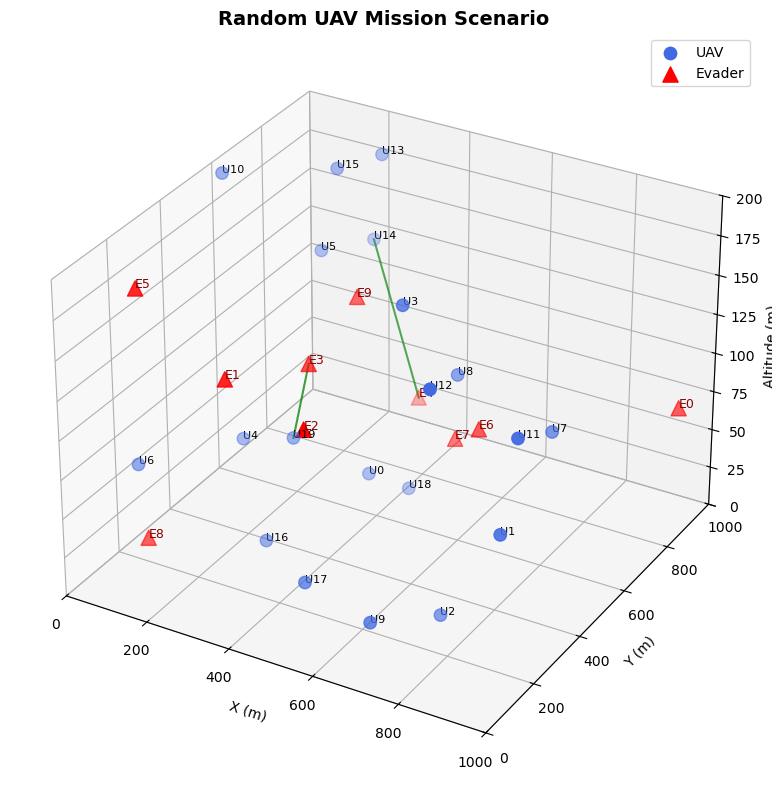

In [15]:
# @title
# =============================================================================
# 7. GRAPH VISUALIZATION
# =============================================================================
#
# Corresponds to Sections 4 and 6 of the manuscript.
#
# Purpose
# -------
# This section provides visual representations of the generated mission
# scenarios and their associated assignment graphs.
#
# The visualization serves two purposes:
#
#   • Verify the correctness of the generated benchmark instances.
#
#   • Provide an intuitive illustration of the fuzzy coalition formation
#     process described in the manuscript.
#
# The reviewer specifically requested an illustrative tactical example.
#
# The functions implemented here can visualize:
#
#   1. UAV deployment
#   2. Evader locations
#   3. Candidate assignment edges
#   4. Alpha-cut graph
#   5. Final coalitions (later)
#
# =============================================================================

from mpl_toolkits.mplot3d import Axes3D


def plot_mission(mission,
                 show_assignments=True,
                 membership_matrix=None,
                 threshold=0.50,
                 figsize=(10, 8)):
    """
    Plot a complete UAV mission in 3D.

    Parameters
    ----------
    mission : dict

        Mission generated by generate_mission().

    show_assignments : bool

        Draw UAV → Evader assignment lines.

    membership_matrix : ndarray or None

        Assignment membership matrix.

    threshold : float

        Minimum assignment membership to display.

    figsize : tuple

        Figure size.

    Returns
    -------
    fig, ax

    Notes
    -----
    This visualization is intended for qualitative inspection and for
    generating publication figures.
    """

    fig = plt.figure(figsize=figsize)

    ax = fig.add_subplot(111, projection='3d')

    # -------------------------------------------------------------------------
    # UAVs
    # -------------------------------------------------------------------------

    positions = mission["positions"]

    ux = positions[:, 0]
    uy = positions[:, 1]
    uz = positions[:, 2]
    ax.scatter(
        ux,
        uy,
        uz,
        s=80,
        c="royalblue",
        marker="o",
        label="UAV"
    )

    # UAV labels

    for i in range(len(ux)):
        ax.text(
            ux[i],
            uy[i],
            uz[i],
            f"U{i}",
            fontsize=8
        )

    # -------------------------------------------------------------------------
    # Evaders
    # -------------------------------------------------------------------------

    evaders = mission["evaders"]

    ex = evaders[:, 0]
    ey = evaders[:, 1]
    ez = evaders[:, 2]

    ax.scatter(
        ex,
        ey,
        ez,
        s=120,
        c="red",
        marker="^",
        label="Evader"
    )

    # Evader labels

    for j in range(len(ex)):
        ax.text(
            ex[j],
            ey[j],
            ez[j],
            f"E{j}",
            fontsize=9,
            color="darkred"
        )

    # -------------------------------------------------------------------------
    # Assignment edges
    # -------------------------------------------------------------------------

    if show_assignments and membership_matrix is not None:

        num_uavs = membership_matrix.shape[0]
        num_evaders = membership_matrix.shape[1]

        for i in range(num_uavs):

            for j in range(num_evaders):

                mu = membership_matrix[i, j]

                if mu < threshold:
                    continue

                ax.plot(
                    [ux[i], ex[j]],
                    [uy[i], ey[j]],
                    [uz[i], ez[j]],
                    linewidth=1.5,
                    alpha=mu,
                    color="green"
                )

    # -------------------------------------------------------------------------
    # Formatting
    # -------------------------------------------------------------------------

    ax.set_xlim(0, FLIGHT_SPACE_X)
    ax.set_ylim(0, FLIGHT_SPACE_Y)
    ax.set_zlim(0, FLIGHT_SPACE_Z)

    ax.set_xlabel("X (m)")
    ax.set_ylabel("Y (m)")
    ax.set_zlabel("Altitude (m)")

    ax.set_title(
        "Random UAV Mission Scenario",
        fontsize=14,
        fontweight="bold"
    )

    ax.legend()

    plt.tight_layout()

    return fig, ax


# =============================================================================
# Example
# =============================================================================

# Generate one mission
mission = generate_mission(
    num_uavs=20,
    seed=RANDOM_SEED
)

# Compute the membership matrix
membership_matrix = compute_all_memberships(
    mission["positions"],
    mission["velocities"],
    mission["battery"],
    mission["evaders"]
)

# Visualize the mission
fig, ax = plot_mission(
    mission,
    membership_matrix=membership_matrix,
    threshold=ALPHA_CUT
)

plt.show()

In [16]:
# @title
from collections import deque

# =============================================================================
# Deterministic Fuzzy Pivoted Iterative Refinement (F-PIR)
# =============================================================================
#
# Deterministic implementation of Algorithm 1.
#
# Deterministic properties
# ------------------------
# 1. Pivot vertices are visited in ascending vertex order.
# 2. Candidate vertices are expanded in ascending order.
# 3. Maximal coalitions are returned in deterministic order.
#
# Configuration
# -------------
#
# Γ = (R, P, X)
#
# R : current coalition
# P : candidate vertices
# X : processed vertices
#
# =============================================================================

def fpir(graph, minimum_size=2):

    # -------------------------------------------------------------------------
    # Output
    # -------------------------------------------------------------------------

    maximal_coalitions = []

    statistics = {

        "configurations": 0,

        "maximum_frontier": 0

    }

    # -------------------------------------------------------------------------
    # Initial configuration
    #
    # Γ0 = (∅, V, ∅)
    # -------------------------------------------------------------------------

    frontier = deque()

    frontier.append(

        (
            set(),
            set(graph.nodes()),
            set()
        )

    )

    # -------------------------------------------------------------------------
    # Main refinement loop
    # -------------------------------------------------------------------------

    while frontier:

        statistics["maximum_frontier"] = max(

            statistics["maximum_frontier"],
            len(frontier)

        )

        # ---------------------------------------------------------------------
        # Next configuration (LIFO frontier)
        # ---------------------------------------------------------------------

        R, P, X = frontier.pop()

        statistics["configurations"] += 1

        # ---------------------------------------------------------------------
        # Terminal configuration
        # ---------------------------------------------------------------------

        if not P and not X:

            if len(R) >= minimum_size:

                maximal_coalitions.append(

                    sorted(R)

                )

            continue

        # ---------------------------------------------------------------------
        # Step 1
        # Deterministic fuzzy pivot selection
        #
        # Priority:
        #
        #   1. Maximum number of neighbors in P
        #   2. Maximum total fuzzy weight
        #   3. Smallest vertex identifier
        #
        # The third criterion is automatically satisfied because vertices are
        # visited in ascending order and the pivot is updated only on a strict
        # improvement.
        # ---------------------------------------------------------------------

        best_pivot = None

        best_degree = -1

        best_weight = -1.0

        for u in sorted(P | X):

            neighbors = P & set(graph.neighbors(u))

            degree = len(neighbors)

            weight = sum(

                graph[u][v]["weight"]

                for v in neighbors

            )

            if degree > best_degree:

                best_degree = degree

                best_weight = weight

                best_pivot = u

            elif degree == best_degree and weight > best_weight:

                best_degree = degree

                best_weight = weight

                best_pivot = u

        # ---------------------------------------------------------------------
        # Step 2
        # Deterministic refinement candidates
        # ---------------------------------------------------------------------

        if best_pivot is None:

            candidates = sorted(P)

        else:

            candidates = sorted(

                P - set(graph.neighbors(best_pivot))

            )

        # ---------------------------------------------------------------------
        # Step 3
        # Generate successor configurations
        # ---------------------------------------------------------------------

        for vertex in candidates:

            neighbors = set(

                graph.neighbors(vertex)

            )

            frontier.append(

                (
                    R | {vertex},
                    P & neighbors,
                    X & neighbors
                )

            )

            P.remove(vertex)

            X.add(vertex)

    # -------------------------------------------------------------------------
    # Deterministic output ordering
    #
    # Largest coalitions first.
    # Lexicographic order for equal-sized coalitions.
    # -------------------------------------------------------------------------

    maximal_coalitions.sort(

        key=lambda coalition: (

            -len(coalition),

            coalition

        )

    )

    statistics["coalitions"] = len(

        maximal_coalitions

    )

    return maximal_coalitions, statistics

In [17]:

# @title

# =============================================================================
# Benchmark Timer — Robust F-PIR Timing
# =============================================================================

def benchmark_fpir(graph,
                   membership_matrix,
                   repetitions=7,
                   warmup_runs=2):
    """
    Execute F-PIR repeatedly and measure its execution time robustly.

    Parameters
    ----------
    graph : NetworkX graph
        Alpha-cut compatibility graph.

    membership_matrix : ndarray
        Original fuzzy membership matrix.
        Kept for interface compatibility and reproducibility.

    repetitions : int, default=7
        Number of timed F-PIR executions.

    warmup_runs : int, default=2
        Number of untimed warm-up executions.

    Returns
    -------
    result : dict
        execution_time :
            Median execution time over the timed repetitions.

        execution_time_std :
            Standard deviation of the timed repetitions.

        execution_times :
            Individual measured execution times.

        maximal_cliques :
            Maximal coalitions returned by the final F-PIR execution.

        statistics :
            F-PIR search statistics.
    """

    # -------------------------------------------------------------------------
    # Warm-up phase
    #
    # These executions are not included in the benchmark measurements.
    # They reduce effects from Python/OS initialization and first-run overhead.
    # -------------------------------------------------------------------------

    for _ in range(warmup_runs):

        fpir(
            graph,
            minimum_size=2
        )

    # -------------------------------------------------------------------------
    # Timed executions
    # -------------------------------------------------------------------------

    execution_times = []

    maximal_cliques = None
    statistics = None

    for _ in range(repetitions):

        start_time = time.perf_counter()

        maximal_cliques, statistics = fpir(
            graph,
            minimum_size=2
        )

        end_time = time.perf_counter()

        execution_times.append(
            end_time - start_time
        )

    # -------------------------------------------------------------------------
    # Robust timing statistics
    # -------------------------------------------------------------------------

    execution_time = float(
        np.median(execution_times)
    )

    execution_time_std = float(
        np.std(execution_times, ddof=1)
    ) if len(execution_times) > 1 else 0.0

    # -------------------------------------------------------------------------
    # Return benchmark result
    # -------------------------------------------------------------------------

    return {

        "execution_time":
            execution_time,

        "execution_time_std":
            execution_time_std,

        "execution_times":
            execution_times,

        "maximal_cliques":
            maximal_cliques,

        "statistics":
            statistics
    }



In [18]:

# @title

# =============================================================================
# Single Monte Carlo Experiment
# =============================================================================

def run_single_experiment(
    num_uavs,
    alpha=ALPHA_CUT,
    seed=None
):
    """
    Execute one complete Monte Carlo experiment.

    Workflow
    --------
        Mission
            ↓
        Membership computation
            ↓
        Fuzzy graph
            ↓
        Alpha-cut
            ↓
        F-PIR benchmark
            ↓
        Statistics

    Parameters
    ----------
    num_uavs : int
        Number of UAVs in the mission.

    alpha : float
        Alpha-cut threshold.

    seed : int, optional
        Random seed used to generate the mission.

    Returns
    -------
    result : dict
        Experiment results and F-PIR statistics.
    """

    # -------------------------------------------------------------------------
    # 1. Generate mission
    # -------------------------------------------------------------------------

    mission = generate_mission(
        num_uavs=num_uavs,
        seed=seed
    )

    # -------------------------------------------------------------------------
    # 2. Compute fuzzy membership matrix
    # -------------------------------------------------------------------------

    membership_matrix = compute_all_memberships(
        mission["positions"],
        mission["velocities"],
        mission["battery"],
        mission["evaders"]
    )

    # -------------------------------------------------------------------------
    # 3. Construct fuzzy compatibility graph
    # -------------------------------------------------------------------------

    fuzzy_graph = build_fuzzy_graph(
        membership_matrix
    )

    # -------------------------------------------------------------------------
    # 4. Apply alpha-cut
    # -------------------------------------------------------------------------

    alpha_graph = alpha_cut_graph(
        fuzzy_graph,
        alpha
    )

    # -------------------------------------------------------------------------
    # 5. Benchmark F-PIR
    #
    # benchmark_fpir performs its own warm-up and repeated timing.
    # -------------------------------------------------------------------------

    benchmark = benchmark_fpir(
        alpha_graph,
        membership_matrix
    )

    # -------------------------------------------------------------------------
    # 6. Extract coalition statistics
    # -------------------------------------------------------------------------

    maximal_coalitions = benchmark["maximal_cliques"]

    result = {

        "num_uavs":
            num_uavs,

        "alpha":
            alpha,

        "seed":
            seed,

        # Robust execution-time estimate:
        # median over the repeated F-PIR executions.
        "execution_time":
            benchmark["execution_time"],

        # Variation among repeated executions of the SAME graph.
        "execution_time_std":
            benchmark["execution_time_std"],

        "num_coalitions":
            len(maximal_coalitions),

        "largest_coalition":
            max(
                (len(c) for c in maximal_coalitions),
                default=0
            )
    }

    # -------------------------------------------------------------------------
    # 7. Add F-PIR search statistics
    # -------------------------------------------------------------------------

    result.update(
        benchmark["statistics"]
    )

    return result



In [19]:
# @title
# =============================================================================
# Monte Carlo Benchmark
# =============================================================================

def run_monte_carlo(num_uavs,
                    alpha=ALPHA_CUT):
    """
    Execute NUM_MONTE_CARLO_RUNS independent experiments.

    Returns
    -------
    pandas.DataFrame
    """

    results = []

    for run in range(NUM_MONTE_CARLO_RUNS):

        seed = RANDOM_SEED + run

        results.append(

            run_single_experiment(

                num_uavs=num_uavs,

                alpha=alpha,

                seed=seed

            )

        )

    return pd.DataFrame(results)

In [20]:
# @title
# =============================================================================
# Scalability Benchmark
# =============================================================================

def scalability_benchmark():
    """
    Evaluate F-PIR for every swarm size.

    Returns
    -------
    DataFrame
    """

    summary = []

    for n in UAV_SIZES:

        print(f"Running {n} UAVs...")

        df = run_monte_carlo(n)

        summary.append({

            "UAVs":

                n,

            "Mean Time":

                df["execution_time"].mean(),

            "Std Time":

                df["execution_time"].std(),

            "Mean Coalitions":

                df["num_coalitions"].mean(),

            "Mean Largest Coalition":

                df["largest_coalition"].mean(),
            "Generated Configurations":

               df["configurations"].mean(),

            "Maximum Frontier":

               df["maximum_frontier"].mean()
        })

    return pd.DataFrame(summary)

In [21]:
# @title
# =============================================================================
# Alpha Sensitivity Analysis
# =============================================================================

def alpha_sensitivity():
    """
    Evaluate every alpha threshold.

    Returns
    -------
    DataFrame
    """

    results = []

    for alpha in ALPHA_VALUES:

        print(f"Alpha = {alpha:.2f}")

        df = run_monte_carlo(

            UAV_SIZES[-1],

            alpha

        )

        results.append({

    "Alpha":
        alpha,

    "Execution Time":
        df["execution_time"].mean(),

    "Coalitions":
        df["num_coalitions"].mean(),

    "Configurations":
        df["configurations"].mean(),

    "Maximum Frontier":
        df["maximum_frontier"].mean()

})

    return pd.DataFrame(results)

In [22]:
# @title
# =============================================================================
# Parallel Benchmark
# =============================================================================

def parallel_scalability():
    """
    Execute the scalability benchmark using multiple CPU cores.
    """

    print("Parallel benchmark")

    return Parallel(

        n_jobs=NUM_WORKERS

    )(

        delayed(run_monte_carlo)(n)

        for n in UAV_SIZES

    )

In [23]:

# @title

# =============================================================================
# Monte Carlo Experiments
# =============================================================================
#
# Perform repeated independent mission simulations and evaluate the
# statistical behaviour of F-PIR.
#
# Each Monte Carlo run uses a deterministic, independent seed:
#
#     seed = RANDOM_SEED + run
#
# The F-PIR timing itself is handled by benchmark_fpir(), which performs
# warm-up executions and repeated timed executions on the same graph.
#
# Returns
# -------
# pandas.DataFrame
#     One row per independent mission experiment.
#
# =============================================================================

def monte_carlo_experiments(
    num_uavs=50,
    alpha=ALPHA_CUT,
    runs=NUM_MONTE_CARLO_RUNS
):
    """
    Execute independent Monte Carlo experiments.

    Parameters
    ----------
    num_uavs : int
        Number of UAVs in each mission.

    alpha : float
        Alpha-cut threshold.

    runs : int
        Number of independent Monte Carlo experiments.

    Returns
    -------
    pandas.DataFrame
        One row per Monte Carlo experiment.
    """

    results = []

    # -------------------------------------------------------------------------
    # Independent Monte Carlo experiments
    # -------------------------------------------------------------------------

    for run in range(runs):

        # Deterministic and reproducible seed for this experiment.
        #
        # Different runs therefore generate independent mission instances,
        # while the complete experiment remains reproducible.
        seed = RANDOM_SEED + run

        result = run_single_experiment(
            num_uavs=num_uavs,
            alpha=alpha,
            seed=seed
        )

        # Human-readable experiment index.
        result["run"] = run + 1

        results.append(result)

    # -------------------------------------------------------------------------
    # Convert results to DataFrame
    # -------------------------------------------------------------------------

    return pd.DataFrame(results)



In [24]:
# @title
# =============================================================================
# Monte Carlo Statistics
# =============================================================================

def monte_carlo_statistics(df):

    summary = pd.DataFrame({

        "Metric":[

            "Execution Time",

            "Number of Coalitions",

            "Largest Coalition",

            "Configurations",

            "Maximum Frontier"

        ],

        "Mean":[

            df["execution_time"].mean(),

            df["num_coalitions"].mean(),

            df["largest_coalition"].mean(),

            df["configurations"].mean(),

            df["maximum_frontier"].mean()

        ],

        "Std":[

            df["execution_time"].std(),

            df["num_coalitions"].std(),

            df["largest_coalition"].std(),

            df["configurations"].std(),

            df["maximum_frontier"].std()

        ],

        "Minimum":[

            df["execution_time"].min(),

            df["num_coalitions"].min(),

            df["largest_coalition"].min(),

            df["configurations"].min(),

            df["maximum_frontier"].min()

        ],

        "Maximum":[

            df["execution_time"].max(),

            df["num_coalitions"].max(),

            df["largest_coalition"].max(),

            df["configurations"].max(),

            df["maximum_frontier"].max()

        ]

    })

    return summary

In [25]:

# @title

# =============================================================================
# Statistical Analysis — Robust Monte Carlo Statistics
# =============================================================================
#
# Compute descriptive statistics and bootstrap confidence intervals
# from Monte Carlo experiments.
#
# The execution-time distribution may be strongly right-skewed.
# Therefore, normal/t-based confidence intervals are not used for
# execution time. Instead, non-parametric bootstrap confidence
# intervals are computed.
#
# Reported statistics:
#
#   Mean
#   Standard deviation
#   Median
#   Minimum
#   Maximum
#   Q1
#   Q3
#   95% bootstrap CI
#
# =============================================================================

import numpy as np
import pandas as pd


def bootstrap_ci(
    values,
    statistic=np.mean,
    confidence=CONFIDENCE_LEVEL,
    bootstrap_samples=10000,
    seed=RANDOM_SEED
):
    """
    Compute a non-parametric bootstrap confidence interval.

    Parameters
    ----------
    values : array-like
        Observed samples.

    statistic : callable
        Statistic to bootstrap, e.g. np.mean or np.median.

    confidence : float
        Confidence level, e.g. 0.95.

    bootstrap_samples : int
        Number of bootstrap resamples.

    seed : int
        Random seed for reproducibility.

    Returns
    -------
    lower : float
        Lower confidence bound.

    upper : float
        Upper confidence bound.
    """

    values = np.asarray(values, dtype=float)

    values = values[np.isfinite(values)]

    n = len(values)

    if n == 0:
        return np.nan, np.nan

    if n == 1:
        value = float(statistic(values))
        return value, value

    rng = np.random.default_rng(seed)

    # -------------------------------------------------------------------------
    # Generate bootstrap samples
    # -------------------------------------------------------------------------

    bootstrap_indices = rng.integers(
        0,
        n,
        size=(bootstrap_samples, n)
    )

    bootstrap_samples_values = values[
        bootstrap_indices
    ]

    # -------------------------------------------------------------------------
    # Compute bootstrap statistic
    # -------------------------------------------------------------------------

    bootstrap_statistics = np.array(
        [
            statistic(sample)
            for sample in bootstrap_samples_values
        ],
        dtype=float
    )

    # -------------------------------------------------------------------------
    # Percentile confidence interval
    # -------------------------------------------------------------------------

    alpha = 1.0 - confidence

    lower = np.percentile(
        bootstrap_statistics,
        100.0 * alpha / 2.0
    )

    upper = np.percentile(
        bootstrap_statistics,
        100.0 * (1.0 - alpha / 2.0)
    )

    return float(lower), float(upper)


# =============================================================================
# Statistical Analysis
# =============================================================================

def statistical_analysis(results):
    """
    Compute descriptive statistics and robust bootstrap confidence intervals.

    Parameters
    ----------
    results : pandas.DataFrame
        Output of monte_carlo_experiments().

    Returns
    -------
    pandas.DataFrame
        Statistical summary for each experimental metric.
    """

    metrics = [

        "execution_time",

        "num_coalitions",

        "largest_coalition",

        "configurations",

        "maximum_frontier"

    ]

    rows = []

    confidence = CONFIDENCE_LEVEL

    # -------------------------------------------------------------------------
    # Analyze each metric independently
    # -------------------------------------------------------------------------

    for metric_index, metric in enumerate(metrics):

        values = results[metric].to_numpy(
            dtype=float
        )

        # Remove invalid numerical values if any.
        values = values[
            np.isfinite(values)
        ]

        n = len(values)

        if n == 0:
            continue

        # ---------------------------------------------------------------------
        # Descriptive statistics
        # ---------------------------------------------------------------------

        mean = float(
            np.mean(values)
        )

        std = float(
            np.std(
                values,
                ddof=1
            )
        ) if n > 1 else 0.0

        median = float(
            np.median(values)
        )

        minimum = float(
            np.min(values)
        )

        maximum = float(
            np.max(values)
        )

        q1 = float(
            np.percentile(
                values,
                25
            )
        )

        q3 = float(
            np.percentile(
                values,
                75
            )
        )

        # ---------------------------------------------------------------------
        # Bootstrap CI for the mean
        #
        # A different deterministic seed is used for each metric so that
        # bootstrap resampling remains reproducible without coupling the
        # random streams of different metrics.
        # ---------------------------------------------------------------------

        mean_ci_lower, mean_ci_upper = bootstrap_ci(

            values,

            statistic=np.mean,

            confidence=confidence,

            bootstrap_samples=10000,

            seed=RANDOM_SEED + metric_index

        )

        # ---------------------------------------------------------------------
        # Bootstrap CI for the median
        #
        # Particularly useful for execution time because the timing
        # distribution may contain rare but very large outliers.
        # ---------------------------------------------------------------------

        median_ci_lower, median_ci_upper = bootstrap_ci(

            values,

            statistic=np.median,

            confidence=confidence,

            bootstrap_samples=10000,

            seed=RANDOM_SEED + 100 + metric_index

        )

        # ---------------------------------------------------------------------
        # Store results
        # ---------------------------------------------------------------------

        rows.append({

            "Metric":
                metric,

            "N":
                n,

            "Mean":
                mean,

            "Std":
                std,

            "Median":
                median,

            "Minimum":
                minimum,

            "Maximum":
                maximum,

            "Q1":
                q1,

            "Q3":
                q3,

            "IQR":
                q3 - q1,

            "95% CI Mean Lower":
                mean_ci_lower,

            "95% CI Mean Upper":
                mean_ci_upper,

            "95% CI Median Lower":
                median_ci_lower,

            "95% CI Median Upper":
                median_ci_upper

        })

    return pd.DataFrame(rows)



In [26]:
# @title
import os
import pandas as pd


# =============================================================================
# Generate All Tables
# =============================================================================

def generate_tables(
    scalability_df,
    alpha_df,
    statistics_df
):
    """
    Save every experimental table.

    Parameters
    ----------
    scalability_df : DataFrame

    alpha_df : DataFrame

    statistics_df : DataFrame
    """

    os.makedirs(TABLES_DIRECTORY, exist_ok=True)

    tables = {

        "Table_1_Scalability.csv":
            scalability_df,

        "Table_2_Alpha_Sensitivity.csv":
            alpha_df,

        "Table_3_Statistical_Analysis.csv":
            statistics_df

    }

    for filename, dataframe in tables.items():

        path = os.path.join(

            TABLES_DIRECTORY,
            filename

        )

        dataframe.to_csv(

            path,
            index=False

        )

        print(f"Saved {path}")

    return tables

In [27]:
# @title
import matplotlib.pyplot as plt


# =============================================================================
# Save Figure
# =============================================================================

def save_current_figure(filename):

    os.makedirs(

        FIGURES_DIRECTORY,
        exist_ok=True

    )

    plt.tight_layout()

    plt.savefig(

        os.path.join(

            FIGURES_DIRECTORY,
            filename + ".png"

        ),

        dpi=300

    )

    plt.savefig(

        os.path.join(

            FIGURES_DIRECTORY,
            filename + ".pdf"

        )

    )

    plt.close()

In [28]:
# @title
def figure_execution_time(df):

    plt.figure(figsize=(7,5))

    plt.plot(

        df["UAVs"],
        df["Mean Time"],
        marker="o"

    )

    plt.xlabel("Number of UAVs")

    plt.ylabel("Execution Time (s)")

    plt.grid(True)

    save_current_figure(

        "Figure_1_Execution_Time"

    )

In [29]:
# @title
def figure_coalitions(df):

    plt.figure(figsize=(7,5))

    plt.plot(

        df["UAVs"],
        df["Mean Coalitions"],
        marker="s"

    )

    plt.xlabel("Number of UAVs")

    plt.ylabel("Mean Coalitions")

    plt.grid(True)

    save_current_figure(

        "Figure_2_Coalitions"

    )

In [30]:
# @title
def figure_largest_coalition(df):

    plt.figure(figsize=(7,5))

    plt.plot(

        df["UAVs"],
        df["Mean Largest Coalition"],
        marker="^"

    )

    plt.xlabel("Number of UAVs")

    plt.ylabel("Largest Coalition")

    plt.grid(True)

    save_current_figure(

        "Figure_3_Largest_Coalition"

    )

In [31]:
# @title
def figure_configurations(df):

    plt.figure(figsize=(7,5))

    plt.plot(

        df["UAVs"],
        df["Generated Configurations"],
        marker="d"

    )

    plt.xlabel("Number of UAVs")

    plt.ylabel("Configurations")

    plt.grid(True)

    save_current_figure(

        "Figure_4_Configurations"

    )

In [32]:
# @title
def figure_frontier(df):

    plt.figure(figsize=(7,5))

    plt.plot(

        df["UAVs"],
        df["Maximum Frontier"],
        marker="o"

    )

    plt.xlabel("Number of UAVs")

    plt.ylabel("Maximum Frontier")

    plt.grid(True)

    save_current_figure(

        "Figure_5_Frontier"

    )

In [33]:
# @title
def figure_alpha(alpha_df):

    plt.figure(figsize=(7,5))

    plt.plot(

        alpha_df["Alpha"],
        alpha_df["Execution Time"],
        marker="o"

    )

    plt.xlabel(r"$\alpha$")

    plt.ylabel("Execution Time (s)")

    plt.grid(True)

    save_current_figure(

        "Figure_6_Alpha"

    )

In [34]:
# @title
def figure_boxplot(monte_carlo_df):

    plt.figure(figsize=(7,5))

    plt.boxplot(

        monte_carlo_df["execution_time"]

    )

    plt.ylabel("Execution Time (s)")

    plt.grid(True)

    save_current_figure(

        "Figure_7_Boxplot"

    )

In [35]:
# @title
def generate_figures(
    scalability_df,
    alpha_df,
    monte_carlo_df
):
    """
    Generate every publication figure.
    """

    figure_execution_time(
        scalability_df
    )

    figure_coalitions(
        scalability_df
    )

    figure_largest_coalition(
        scalability_df
    )

    figure_configurations(
        scalability_df
    )

    figure_frontier(
        scalability_df
    )

    figure_alpha(
        alpha_df
    )

    figure_boxplot(
        monte_carlo_df
    )

    print("\nAll figures generated.")

In [36]:
# @title
# Run experiments

NUM_MONTE_CARLO_RUNS = 200

scalability_df = scalability_benchmark()

alpha_df = alpha_sensitivity()

monte_carlo_df = run_monte_carlo(
    UAV_SIZES[-1]
)

statistics_df = statistical_analysis(
    monte_carlo_df
)

# Generate tables

generate_tables(

    scalability_df,

    alpha_df,

    statistics_df

)

# Generate figures

generate_figures(

    scalability_df,

    alpha_df,

    monte_carlo_df

)

Running 10 UAVs...
Running 20 UAVs...
Running 30 UAVs...
Running 40 UAVs...
Running 50 UAVs...
Running 60 UAVs...
Running 70 UAVs...
Running 80 UAVs...
Running 90 UAVs...
Running 100 UAVs...
Alpha = 0.40
Alpha = 0.50
Alpha = 0.60
Alpha = 0.70
Alpha = 0.80
Saved results/tables\Table_1_Scalability.csv
Saved results/tables\Table_2_Alpha_Sensitivity.csv
Saved results/tables\Table_3_Statistical_Analysis.csv

All figures generated.
